# 🧬 Revisión de Datasets Genómicos — CIP Dataverse

**Objetivo:** Explorar y resumir los datasets de genotipado (DArTSeq, SilicoDArT, SNP) disponibles para Sweetpotato, Yacon, Ulluco, Oca y Mashua.

> ⚠️ Varios archivos son muy grandes (hasta 658 MB), por lo que se usan técnicas de muestreo y lectura eficiente.

In [33]:
import pandas as pd
import numpy as np
import json
import os
import csv
import subprocess
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

DATA_DIR = Path("/home/rosewt-dell/Code/Oxor/data")

# Cargar metadata
with open(DATA_DIR / "metadata.json") as f:
    metadata = json.load(f)

print("✅ Librerías y metadata cargadas")

✅ Librerías y metadata cargadas


## 1. Catálogo de Datasets

Convertimos el `metadata.json` en una tabla para ver el panorama completo.

In [34]:
# Crear tabla resumen del catálogo
rows = []
for crop, datasets in metadata.items():
    for ds in datasets:
        rows.append({
            "Cultivo": crop,
            "Tipo": ds.get("type", ""),
            "DOI": ds.get("doi", ""),
            "Carpeta": ds.get("folder", "—"),
            "Restringido": "🔒 Sí" if ds.get("restricted", False) else "✅ No"
        })

catalogo = pd.DataFrame(rows)
print(f"Total de datasets catalogados: {len(catalogo)}")
print(f"Cultivos: {catalogo['Cultivo'].nunique()} — {', '.join(catalogo['Cultivo'].unique())}")
print(f"Restringidos: {(catalogo['Restringido'] == '🔒 Sí').sum()} / {len(catalogo)}")
print()
catalogo

Total de datasets catalogados: 11
Cultivos: 5 — Sweetpotato, Yacon, Ulluco, Oca, Mashua
Restringidos: 7 / 11



,Cultivo,Tipo,DOI,Carpeta,Restringido
0,Sweetpotato,low-density DArTSeq,https://doi.org/10.21223/P3/UBDJ44,10.21223P3UBDJ44_LowDensity,✅ No
1,Sweetpotato,DArTag 3.1K amplicones,https://doi.org/10.21223/P3/D3XEEH,—,🔒 Sí
2,Sweetpotato,diversidad global NGS,https://doi.org/10.21223/P3/S2IMOS,10.21223P30BVZYY_Genetic_diversity,✅ No
3,Sweetpotato,wild relatives,https://doi.org/10.21223/P3/3VYY8C,10.21223P33VYY8C_Wild,✅ No
4,Yacon,SNP,https://doi.org/10.21223/P3/JW6UOC,—,✅ No
5,Yacon,SilicoDArT,https://doi.org/10.21223/P3/5KHIK4,—,🔒 Sí
6,Ulluco,300 accesiones SNP,https://doi.org/10.21223/P3/CD01KI,—,🔒 Sí
7,Ulluco,300 accesiones SilicoDArT,https://doi.org/10.21223/P3/IXXW5N,—,🔒 Sí
8,Ulluco,68 accesiones in situ SilicoDArT,https://doi.org/10.21223/P3/FYYLLO,—,🔒 Sí
9,Oca,56 accesiones in situ SilicoDArT,https://doi.org/10.21223/P3/M613LS,—,🔒 Sí


## 2. Verificar Disponibilidad Local

Revisamos qué carpetas existen realmente en disco.

In [35]:
# Verificar existencia de carpetas locales
# Nota: algunos nombres de carpeta tienen espacios al inicio o final
disponibles = []
for crop, datasets in metadata.items():
    for ds in datasets:
        folder = ds.get("folder")
        if folder:
            # Buscar la carpeta (puede tener espacios raros en el nombre)
            path = DATA_DIR / folder
            existe = path.exists()
            if not existe:
                # Buscar con glob por si hay espacios extra
                matches = list(DATA_DIR.glob(f"*{folder.strip()}*"))
                if matches:
                    path = matches[0]
                    existe = True
            if existe:
                disponibles.append({
                    "crop": crop,
                    "type": ds["type"],
                    "folder": str(path),
                    "doi": ds.get("doi", "")
                })
                print(f"  ✅ {crop} — {ds['type']}: {path.name}")
            else:
                print(f"  ❌ {crop} — {ds['type']}: carpeta '{folder}' NO encontrada")
        else:
            status = "🔒 restringido" if ds.get("restricted") else "🌐 sin carpeta local"
            print(f"  ⚠️  {crop} — {ds['type']}: {status}")

print(f"\n📂 Datasets disponibles localmente: {len(disponibles)}")

  ✅ Sweetpotato — low-density DArTSeq: 10.21223P3UBDJ44_LowDensity
  ⚠️  Sweetpotato — DArTag 3.1K amplicones: 🔒 restringido
  ✅ Sweetpotato — diversidad global NGS: 10.21223P30BVZYY_Genetic_diversity
  ✅ Sweetpotato — wild relatives: 10.21223P33VYY8C_Wild
  ⚠️  Yacon — SNP: 🌐 sin carpeta local
  ⚠️  Yacon — SilicoDArT: 🔒 restringido
  ⚠️  Ulluco — 300 accesiones SNP: 🔒 restringido
  ⚠️  Ulluco — 300 accesiones SilicoDArT: 🔒 restringido
  ⚠️  Ulluco — 68 accesiones in situ SilicoDArT: 🔒 restringido
  ⚠️  Oca — 56 accesiones in situ SilicoDArT: 🔒 restringido
  ⚠️  Mashua — 28 accesiones in situ SilicoDArT: 🔒 restringido

📂 Datasets disponibles localmente: 3


## 3. Escanear Archivos y Tamaños

Listamos todos los archivos en las carpetas disponibles con su tamaño.

In [36]:
# Escanear archivos en carpetas disponibles
file_info = []
for ds in disponibles:
    folder = Path(ds["folder"])
    for f in sorted(folder.iterdir()):
        if f.is_file():
            size_mb = f.stat().st_size / (1024 * 1024)
            file_info.append({
                "Cultivo": ds["crop"],
                "Dataset": ds["type"],
                "Archivo": f.name,
                "Extensión": f.suffix,
                "Tamaño (MB)": round(size_mb, 1),
                "path": str(f)
            })

df_files = pd.DataFrame(file_info)
print(f"Total de archivos encontrados: {len(df_files)}")
print(f"Tamaño total: {df_files['Tamaño (MB)'].sum():.0f} MB ({df_files['Tamaño (MB)'].sum()/1024:.1f} GB)")
print()
df_files[["Cultivo", "Dataset", "Archivo", "Tamaño (MB)"]].sort_values("Tamaño (MB)", ascending=False)

Total de archivos encontrados: 9
Tamaño total: 1210 MB (1.2 GB)



,Cultivo,Dataset,Archivo,Tamaño (MB)
4,Sweetpotato,diversidad global NGS,SilicoDArT_Genotypes.csv,657.8
2,Sweetpotato,diversidad global NGS,SNP_Genotypes.csv,229.5
0,Sweetpotato,low-density DArTSeq,01_Report_DSp25-515_SNPs_Filtered_by _reads.csv,96.3
6,Sweetpotato,wild relatives,01_Report_DSp25-515_SNPs_Filtered_by _reads.csv,96.3
1,Sweetpotato,low-density DArTSeq,02_Report_DSp25-515_Silico-DArT_Filtered_by_re...,54.0
7,Sweetpotato,wild relatives,02_SilicoDArT_metrics.csv,49.5
5,Sweetpotato,diversidad global NGS,SilicoDArT_metrics.csv,12.3
8,Sweetpotato,wild relatives,03_SilicoDArT_Data dictionary.xlsx,7.7
3,Sweetpotato,diversidad global NGS,SNP_metrics.csv,6.8


## 4. Dimensiones de cada Dataset (filas × columnas)

Contamos filas con `wc -l` (eficiente) y columnas leyendo solo el header.

In [37]:
# Contar dimensiones de cada CSV sin cargarlo entero
dim_rows = []
for _, row in df_files[df_files["Extensión"] == ".csv"].iterrows():
    filepath = row["path"]
    
    # Contar filas con wc -l
    result = subprocess.run(["wc", "-l", filepath], capture_output=True, text=True)
    n_lines = int(result.stdout.strip().split()[0])
    
    # Detectar delimitador y contar columnas leyendo solo el header
    with open(filepath, 'r') as f:
        header = f.readline().strip()
    
    # Detectar delimitador
    if ';' in header and ',' not in header:
        sep = ';'
    else:
        sep = ','
    
    n_cols = len(header.split(sep))
    
    # Los archivos de genotipos tienen filas de metadatos antes de los datos
    # Identificar si es un archivo de genotipos (muchas columnas = muestras)
    is_genotype = "Genotype" in row["Archivo"] or ("Report" in row["Archivo"])
    
    # Para archivos de genotipos, las columnas de metadata van primero, el resto son muestras
    if is_genotype:
        # Leer las primeras 5 filas para entender la estructura
        try:
            preview = pd.read_csv(filepath, sep=sep, nrows=3, low_memory=False)
            # Columnas numéricas de metadata vs columnas de muestras
            n_marker_cols = sum(1 for c in preview.columns if any(x in str(c).lower() for x in ['clone', 'allele', 'snp', 'call', 'pic', 'freq', 'avg', 'rep', 'chrom', 'cluster', 'ratio', 'depth', 'qpmr', 'aggregate', 'derived', 'total']))
            n_samples = n_cols - n_marker_cols
        except:
            n_samples = "?"
    else:
        n_samples = "N/A (métricas)"
    
    dim_rows.append({
        "Archivo": row["Archivo"],
        "Dataset": row["Dataset"],
        "Filas": n_lines - 1,  # restar header
        "Columnas": n_cols,
        "Delimitador": repr(sep),
        "Muestras (est.)": n_samples,
        "Tamaño (MB)": row["Tamaño (MB)"],
        "Tipo": "Genotipos" if is_genotype else "Métricas"
    })

df_dims = pd.DataFrame(dim_rows)
df_dims

,Archivo,Dataset,Filas,Columnas,Delimitador,Muestras (est.),Tamaño (MB),Tipo
0,01_Report_DSp25-515_SNPs_Filtered_by _reads.csv,low-density DArTSeq,62736,667,"','",635,96.3,Genotipos
1,02_Report_DSp25-515_Silico-DArT_Filtered_by_re...,low-density DArTSeq,38272,650,"','",635,54.0,Genotipos
2,SNP_Genotypes.csv,diversidad global NGS,20103,5971,"','",5971,229.5,Genotipos
3,SNP_metrics.csv,diversidad global NGS,20101,25,"','",N/A (métricas),6.8,Métricas
4,SilicoDArT_Genotypes.csv,diversidad global NGS,57717,5971,"','",5971,657.8,Genotipos
5,SilicoDArT_metrics.csv,diversidad global NGS,57715,14,"','",N/A (métricas),12.3,Métricas
6,01_Report_DSp25-515_SNPs_Filtered_by _reads.csv,wild relatives,62736,667,"','",635,96.3,Genotipos
7,02_SilicoDArT_metrics.csv,wild relatives,236607,15,';',N/A (métricas),49.5,Métricas


## 5. Análisis de Archivos de Métricas (carga completa)

Los archivos `*_metrics.csv` son más pequeños y contienen información de calidad por marcador. Los cargamos completos para analizar estadísticas de calidad.

In [38]:
# --- Cargar archivos de métricas ---
# Encontrar carpetas dinámicamente (los nombres tienen espacios raros)
gen_div_dir = list(DATA_DIR.glob("*Genetic_diversity*"))[0]
wild_dir = list(DATA_DIR.glob("*Wild*"))[0]
lowdens_dir = list(DATA_DIR.glob("*LowDensity*"))[0]

print(f"📁 Diversidad Global: {gen_div_dir.name}")
print(f"📁 Wild Relatives:    {wild_dir.name}")
print(f"📁 Low Density:       {lowdens_dir.name}")

# 1) Diversidad genética - SNP metrics
snp_metrics = pd.read_csv(gen_div_dir / "SNP_metrics.csv", low_memory=False)
print(f"\n📊 Diversidad Global — SNP Metrics: {snp_metrics.shape}")
display(snp_metrics.head(3))
print("\nColumnas:", list(snp_metrics.columns))

📁 Diversidad Global: 10.21223P30BVZYY_Genetic_diversity
📁 Wild Relatives:    10.21223P33VYY8C_Wild
📁 Low Density:       10.21223P3UBDJ44_LowDensity



📊 Diversidad Global — SNP Metrics: (20101, 25)


,AlleleID,CloneID,AlleleSequence,TrimmedSequence,Chrom_SweetPotato_unkn_v4,ChromPos_SweetPotato_unkn_v4,AlnCnt_SweetPotato_unkn_v4,AlnEvalue_SweetPotato_unkn_v4,SNP,SnpPosition,...,FreqHets,PICRef,PICSnp,AvgPIC,AvgCountRef,AvgCountSnp,RepAvg,rdepth,maf,locusName
0,7537914|F|0-35:G>C-35:G>C,7537914,TGCAGAAAACACACATCAAAATTTAGCCAAAAAAAGCTTATTTCAC...,TGCAGAAAACACACATCAAAATTTAGCCAAAAAAAGCTTATTTCAC...,chr9,25074785,1,7.440000e-29,35:G>C,35,...,0.182889,0.205303,0.419221,0.312262,11.55680,6.32501,0.990919,12.1,0.2076,7537914-35-G/C
1,9836526|F|0-49:G>A-49:G>A,9836526,TGCAGAGACAGCAAAATATATAAGATGCAGTAGGAGCAGCAAGTAT...,TGCAGAGACAGCAAAATATATAAGATGCAGTAGGAGCAGCAAGTAT...,chr13,20252981,1,7.440000e-29,49:G>A,49,...,0.069910,0.004413,0.133839,0.069126,8.29695,2.56743,0.984163,8.5,0.0372,9836526-49-G/A
2,7538375|F|0-61:C>A-61:C>A,7538375,TGCAGAGCCTTGAACACTTTACACGTAAACATACTTGAAACAGTAA...,TGCAGAGCCTTGAACACTTTACACGTAAACATACTTGAAACAGTAA...,chr6,36321524,1,1.250000e-26,61:C>A,61,...,0.097383,0.025831,0.196532,0.111182,12.17842,9.50437,0.992129,13.1,0.0618,7538375-61-C/A



Columnas: ['AlleleID', 'CloneID', 'AlleleSequence', 'TrimmedSequence', 'Chrom_SweetPotato_unkn_v4', 'ChromPos_SweetPotato_unkn_v4', 'AlnCnt_SweetPotato_unkn_v4', 'AlnEvalue_SweetPotato_unkn_v4', 'SNP', 'SnpPosition', 'CallRate', 'OneRatioRef', 'OneRatioSnp', 'FreqHomRef', 'FreqHomSnp', 'FreqHets', 'PICRef', 'PICSnp', 'AvgPIC', 'AvgCountRef', 'AvgCountSnp', 'RepAvg', 'rdepth', 'maf', 'locusName']


In [39]:
# 2) Diversidad genética - SilicoDArT metrics
silico_metrics = pd.read_csv(gen_div_dir / "SilicoDArT_metrics.csv", low_memory=False)
print(f"📊 Diversidad Global — SilicoDArT Metrics: {silico_metrics.shape}")
display(silico_metrics.head(3))
print("\nColumnas:", list(silico_metrics.columns))

📊 Diversidad Global — SilicoDArT Metrics: (57715, 14)


,CloneID,AlleleSequence,TrimmedSequence,Chrom_SweetPotato_unkn_v4,ChromPos_SweetPotato_unkn_v4,AlnCnt_SweetPotato_unkn_v4,AlnEvalue_SweetPotato_unkn_v4,CallRate,OneRatio,PIC,AvgReadDepth,StDevReadDepth,Qpmr,Reproducibility
0,7533073,TGCAGTTTCTGGATAATTTCCATCAAATGCTTTGAGAGTTGACCCA...,TGCAGTTTCTGGATAATTTCCATCAAATGCTTTGAGAGTTGACCCA...,chr7,17494872,5,7.440000e-29,0.953936,0.493766,0.499922,11.00324,6.93774,1.61570,0.993373
1,7534016,TGCAGTAAACACAGAAGCCAGAAGGCAATCTCATATTTCAATGATT...,TGCAGTAAACACAGAAGCCAGAAGGCAATCTCATATTTCAATGATT...,*,0,0,9.990000e+02,0.981407,0.216590,0.339357,11.52932,7.33886,1.64967,0.993022
2,7525668,TGCAGAAAAAAAAGCATTTCAGCTCCAACACTCATGAGAAGAAAGA...,TGCAGAAAAAAAAGCATTTCAGCTCCAACACTCATGAGAAGAAAGA...,chr10,25673324,2,5.840000e-20,0.967839,0.390966,0.476223,18.30009,9.95516,1.79897,1.000000



Columnas: ['CloneID', 'AlleleSequence', 'TrimmedSequence', 'Chrom_SweetPotato_unkn_v4', 'ChromPos_SweetPotato_unkn_v4', 'AlnCnt_SweetPotato_unkn_v4', 'AlnEvalue_SweetPotato_unkn_v4', 'CallRate', 'OneRatio', 'PIC', 'AvgReadDepth', 'StDevReadDepth', 'Qpmr', 'Reproducibility']


In [40]:
# 3) Parientes silvestres - SilicoDArT metrics (separador ;)
wild_silico = pd.read_csv(wild_dir / "02_SilicoDArT_metrics.csv", sep=";", low_memory=False)
print(f"📊 Wild Relatives — SilicoDArT Metrics: {wild_silico.shape}")
display(wild_silico.head(3))
print("\nColumnas:", list(wild_silico.columns))

📊 Wild Relatives — SilicoDArT Metrics: (236607, 15)


,CloneID,AlleleSequence,TrimmedSequence,Chrom_SweetPotato_NSP323_v3,ChromPosTag_SweetPotato_NSP323_v3,AlnCnt_SweetPotato_NSP323_v3,AlnEvalue_SweetPotato_NSP323_v3,Strand_SweetPotato_NSP323_v3,CallRate,OneRatio,PIC,AvgReadDepth,StDevReadDepth,Qpmr,Reproducibility
0,7529063,TGCAGCTCTGCTTCTGAAGAATATTGGCCTTCCATCTTACAGATCG...,TGCAGCTCTGCTTCTGAAGAATATTGGCCTTCCATCTTAC,Chr03,4265165,1,7.550000e-13,Minus,0.937378,0.530271,0.498167,35.36655,20.40032,1.73824,0.991632
1,7542258,TGCAGATATTATCATACGAAGGATACAGATTATTCTGCTACATTAC...,TGCAGATATTATCATACGAAGGATACAGATTATTCTGCTACATTAC,Chr04,24172196,1,4.510000e-16,Plus,0.914873,0.500535,0.499999,36.74362,21.56307,1.71891,0.995516
2,7600178,TGCAGTGGGGAATCATGGAATTTAGTGGAGAGGTATAATAGGTGAA...,TGCAGTGGGGAATCATGGAATTTAGTGGAGAGGTATAATAGGTGAA...,Chr11,674238,1,4.200000e-29,Plus,0.933464,0.505241,0.499945,21.62990,13.87480,1.58206,1.000000



Columnas: ['CloneID', 'AlleleSequence', 'TrimmedSequence', 'Chrom_SweetPotato_NSP323_v3', 'ChromPosTag_SweetPotato_NSP323_v3', 'AlnCnt_SweetPotato_NSP323_v3', 'AlnEvalue_SweetPotato_NSP323_v3', 'Strand_SweetPotato_NSP323_v3', 'CallRate', 'OneRatio', 'PIC', 'AvgReadDepth', 'StDevReadDepth', 'Qpmr', 'Reproducibility']


## 6. Estadísticas Descriptivas de Calidad por Dataset

Comparamos las métricas clave de calidad: **CallRate**, **PIC**, **Reproducibility**, **AvgReadDepth**.

In [41]:
# Estadísticas descriptivas de métricas de calidad
metrics_common = ["CallRate", "PIC", "Reproducibility"]

datasets_metrics = {
    "Diversidad Global\n(SNP)": snp_metrics,
    "Diversidad Global\n(SilicoDArT)": silico_metrics,
    "Wild Relatives\n(SilicoDArT)": wild_silico,
}

# Tabla comparativa
comparison = []
for name, df in datasets_metrics.items():
    row = {"Dataset": name, "N marcadores": len(df)}
    for col in metrics_common:
        if col in df.columns:
            row[f"{col} (media)"] = round(df[col].mean(), 4)
            row[f"{col} (mediana)"] = round(df[col].median(), 4)
            row[f"{col} (min)"] = round(df[col].min(), 4)
    # Columnas específicas
    if "AvgReadDepth" in df.columns:
        row["AvgReadDepth (media)"] = round(df["AvgReadDepth"].mean(), 2)
    if "maf" in df.columns:
        row["MAF (media)"] = round(df["maf"].mean(), 4)
    if "AvgPIC" in df.columns:
        row["AvgPIC (media)"] = round(df["AvgPIC"].mean(), 4)
    comparison.append(row)

df_comparison = pd.DataFrame(comparison).set_index("Dataset")
df_comparison

,N marcadores,CallRate (media),CallRate (mediana),CallRate (min),MAF (media),AvgPIC (media),PIC (media),PIC (mediana),PIC (min),Reproducibility (media),Reproducibility (mediana),Reproducibility (min),AvgReadDepth (media)
Dataset,,,,,,,,,,,,,
Diversidad Global\n(SNP),20101,0.9448,0.9781,0.2136,0.2126,0.2297,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Diversidad Global\n(SilicoDArT),57715,0.9679,0.9769,0.8060,NaN,NaN,0.3091,0.3446,0.000,0.9902,0.9945,0.95,18.95
Wild Relatives\n(SilicoDArT),236607,0.9926,0.9980,0.8112,NaN,NaN,0.0735,0.0252,0.002,0.9993,1.0000,0.95,39.23


## 7. Distribuciones de Calidad (CallRate, PIC, Reproducibility)

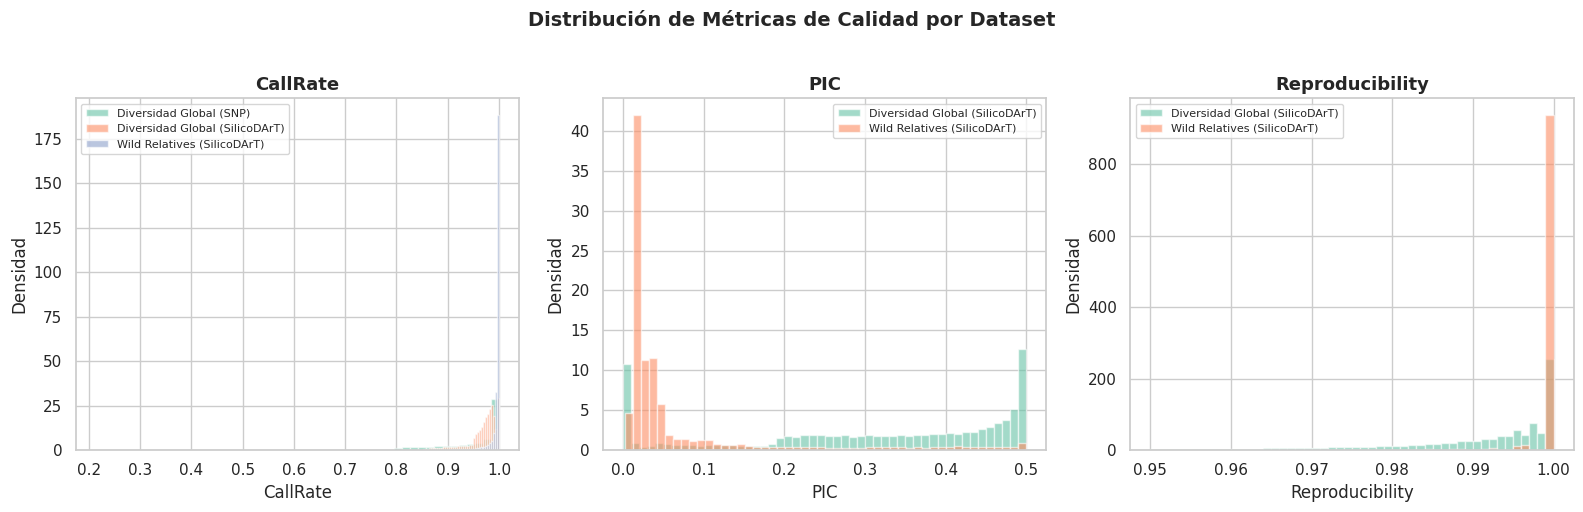

In [42]:
# Distribuciones de CallRate, PIC y Reproducibility por dataset
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, metric in enumerate(["CallRate", "PIC", "Reproducibility"]):
    ax = axes[i]
    for name, df in datasets_metrics.items():
        if metric in df.columns:
            ax.hist(df[metric].dropna(), bins=50, alpha=0.6, label=name.replace('\n', ' '), density=True)
    ax.set_title(metric, fontsize=13, fontweight="bold")
    ax.set_xlabel(metric)
    ax.set_ylabel("Densidad")
    ax.legend(fontsize=8)

plt.suptitle("Distribución de Métricas de Calidad por Dataset", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

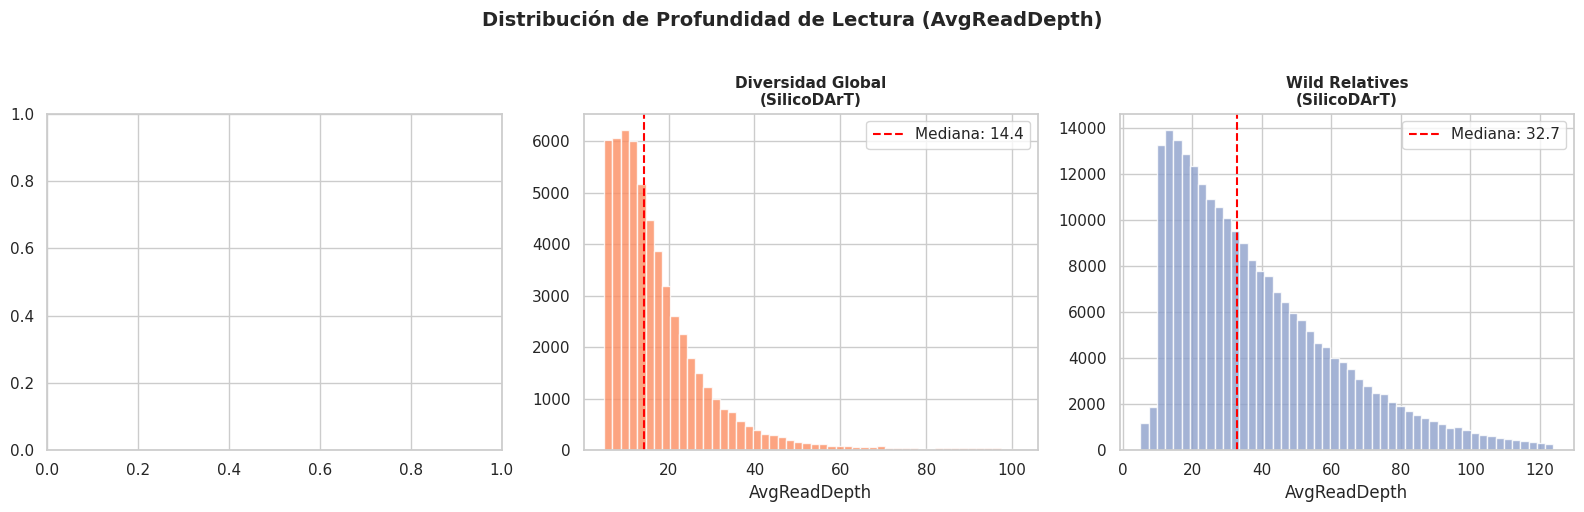

In [43]:
# Distribución de profundidad de lectura
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (name, df) in enumerate(datasets_metrics.items()):
    ax = axes[i]
    col = "AvgReadDepth" if "AvgReadDepth" in df.columns else None
    if col:
        data = df[col].dropna()
        data_clipped = data[data < data.quantile(0.99)]  # quitar outliers extremos
        ax.hist(data_clipped, bins=50, color=sns.color_palette("Set2")[i], alpha=0.8)
        ax.axvline(data.median(), color='red', ls='--', label=f'Mediana: {data.median():.1f}')
        ax.set_title(name, fontsize=11, fontweight="bold")
        ax.set_xlabel("AvgReadDepth")
        ax.legend()

plt.suptitle("Distribución de Profundidad de Lectura (AvgReadDepth)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 8. Missingness en Archivos de Genotipos (muestreo)

Para los archivos de genotipos (grandes), leemos solo una muestra de filas y estimamos el porcentaje de datos faltantes (`-`, `NaN`).

In [44]:
# Muestreo de archivos de genotipos para estimar missingness
genotype_files = {
    "Diversidad Global — SNP Genotypes": gen_div_dir / "SNP_Genotypes.csv",
    "Diversidad Global — SilicoDArT Genotypes": gen_div_dir / "SilicoDArT_Genotypes.csv",
    "Wild — SNP Report": wild_dir / "01_Report_DSp25-515_SNPs_Filtered_by _reads.csv",
    "LowDensity — SNP Report": lowdens_dir / "01_Report_DSp25-515_SNPs_Filtered_by _reads.csv",
    "LowDensity — SilicoDArT Report": lowdens_dir / "02_Report_DSp25-515_Silico-DArT_Filtered_by_reads.csv",
}

miss_results = []
for name, path in genotype_files.items():
    print(f"\n🔍 {name}")
    try:
        # Leer muestra: primeras 500 filas
        sample = pd.read_csv(path, nrows=500, low_memory=False)
        
        # Identificar columnas de muestras (las que NO son métricas)
        meta_keywords = ['allele', 'clone', 'snp', 'call', 'pic', 'freq', 'avg', 'rep', 
                        'chrom', 'cluster', 'ratio', 'depth', 'qpmr', 'aggregate', 
                        'derived', 'total', 'sequence', 'trimmed', 'strand', 'aln',
                        'onerati', 'stdev', 'sample', 'institution', 'locus', 'maf',
                        'rdepth', 'position']
        
        sample_cols = [c for c in sample.columns if not any(k in c.lower() for k in meta_keywords)]
        
        if len(sample_cols) > 10:
            geno_data = sample[sample_cols]
            # Contar missing: '-' o NaN
            total_cells = geno_data.size
            missing_dash = (geno_data == '-').sum().sum()
            missing_nan = geno_data.isna().sum().sum()
            missing_total = missing_dash + missing_nan
            miss_pct = (missing_total / total_cells) * 100
            
            print(f"  Columnas de muestras: {len(sample_cols)}")
            print(f"  Missingness (muestra 500 filas): {miss_pct:.1f}%")
            print(f"    '-': {missing_dash} | NaN: {missing_nan} | Total: {missing_total}/{total_cells}")
            
            miss_results.append({
                "Dataset": name,
                "N muestras (cols)": len(sample_cols),
                "Missingness (%)": round(miss_pct, 1)
            })
        else:
            print(f"  → Pocas columnas de muestra detectadas ({len(sample_cols)}), revisando estructura...")
            print(f"  Columnas totales: {len(sample.columns)}")
    except Exception as e:
        print(f"  ❌ Error: {e}")

if miss_results:
    print("\n" + "="*60)
    df_miss = pd.DataFrame(miss_results)
    display(df_miss)


🔍 Diversidad Global — SNP Genotypes
  Columnas de muestras: 5970
  Missingness (muestra 500 filas): 8.0%
    '-': 238521 | NaN: 0 | Total: 238521/2985000

🔍 Diversidad Global — SilicoDArT Genotypes
  Columnas de muestras: 5970
  Missingness (muestra 500 filas): 2.4%
    '-': 72201 | NaN: 0 | Total: 72201/2985000

🔍 Wild — SNP Report
  Columnas de muestras: 635
  Missingness (muestra 500 filas): 17.6%
    '-': 55956 | NaN: 0 | Total: 55956/317500

🔍 LowDensity — SNP Report
  Columnas de muestras: 635
  Missingness (muestra 500 filas): 17.6%
    '-': 55956 | NaN: 0 | Total: 55956/317500

🔍 LowDensity — SilicoDArT Report
  Columnas de muestras: 635
  Missingness (muestra 500 filas): 9.1%
    '-': 29012 | NaN: 0 | Total: 29012/317500



,Dataset,N muestras (cols),Missingness (%)
0,Diversidad Global — SNP Genotypes,5970,8.0
1,Diversidad Global — SilicoDArT Genotypes,5970,2.4
2,Wild — SNP Report,635,17.6
3,LowDensity — SNP Report,635,17.6
4,LowDensity — SilicoDArT Report,635,9.1


## 9. Comparación Visual entre Datasets

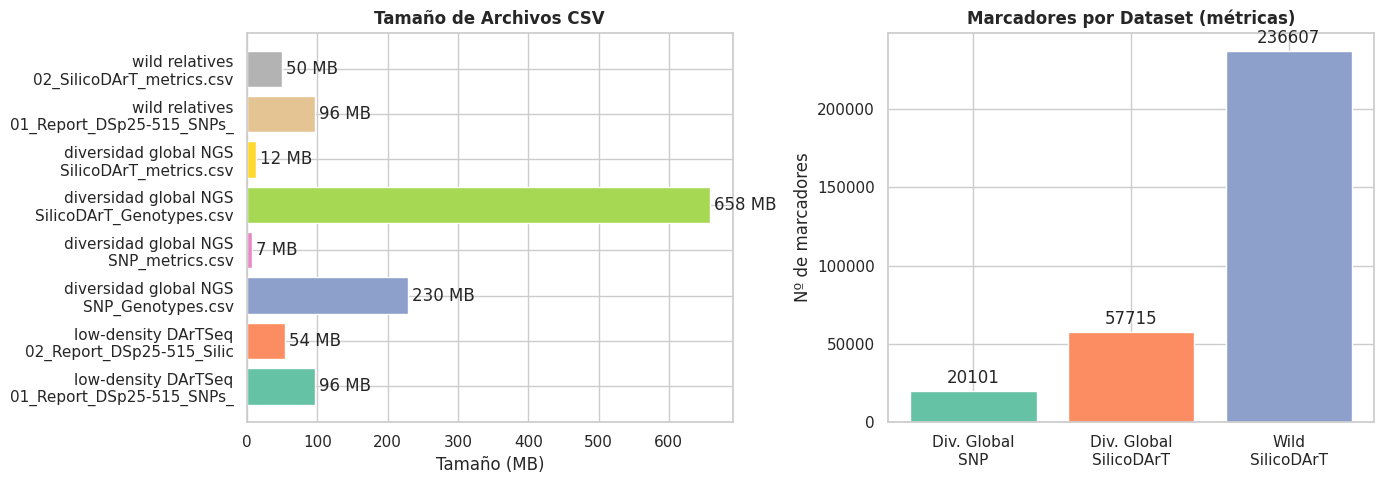

In [45]:
# Gráfico comparativo de tamaños y marcadores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tamaño de archivos
df_csv = df_files[df_files["Extensión"] == ".csv"].copy()
df_csv["Label"] = df_csv["Dataset"] + "\n" + df_csv["Archivo"].str[:25]
ax = axes[0]
bars = ax.barh(df_csv["Label"], df_csv["Tamaño (MB)"], color=sns.color_palette("Set2", len(df_csv)))
ax.set_xlabel("Tamaño (MB)")
ax.set_title("Tamaño de Archivos CSV", fontweight="bold")
ax.bar_label(bars, fmt='%.0f MB', padding=3)

# Número de marcadores en métricas
marker_counts = {
    "Div. Global\nSNP": len(snp_metrics),
    "Div. Global\nSilicoDArT": len(silico_metrics),
    "Wild\nSilicoDArT": len(wild_silico),
}
ax2 = axes[1]
bars2 = ax2.bar(marker_counts.keys(), marker_counts.values(), color=sns.color_palette("Set2", 3))
ax2.set_ylabel("Nº de marcadores")
ax2.set_title("Marcadores por Dataset (métricas)", fontweight="bold")
ax2.bar_label(bars2, fmt='%d', padding=3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_76674/347053584.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=labels, patch_artist=True,
/tmp/ipykernel_76674/347053584.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=labels, patch_artist=True,
/tmp/ipykernel_76674/347053584.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=labels, patch_artist=True,


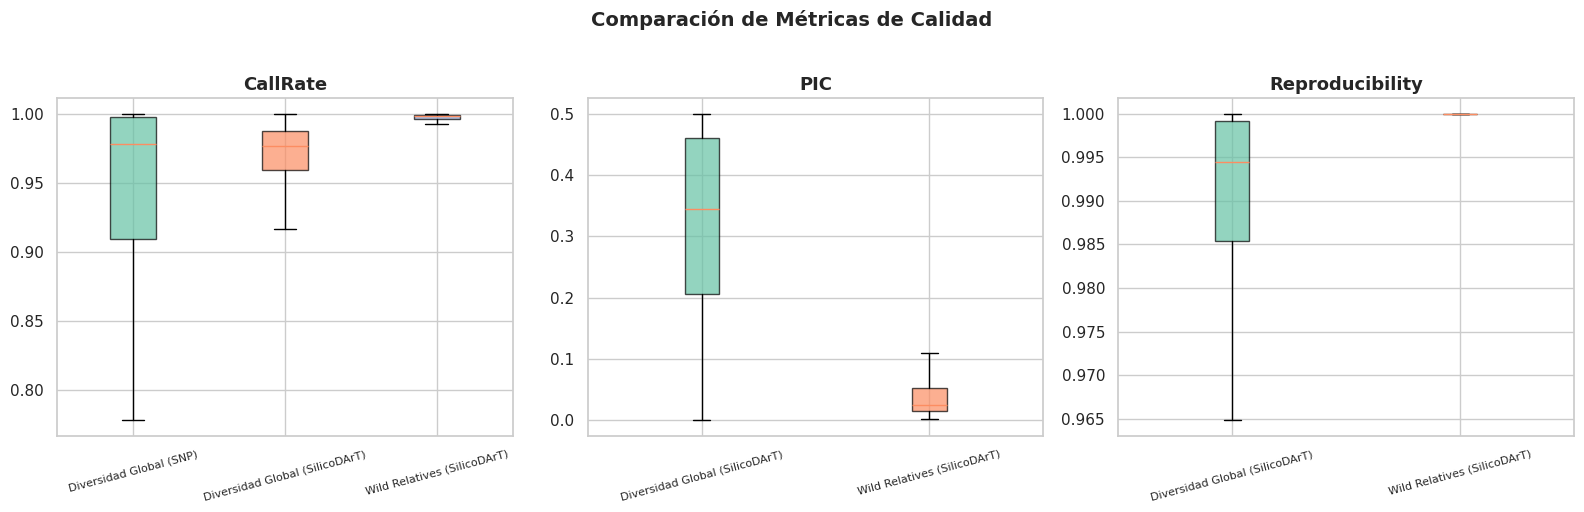

In [46]:
# Boxplots comparativos de métricas de calidad
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, metric in enumerate(["CallRate", "PIC", "Reproducibility"]):
    ax = axes[i]
    plot_data = []
    labels = []
    for name, df in datasets_metrics.items():
        if metric in df.columns:
            plot_data.append(df[metric].dropna().values)
            labels.append(name.replace('\n', ' '))
    
    bp = ax.boxplot(plot_data, labels=labels, patch_artist=True, 
                     boxprops=dict(alpha=0.7), showfliers=False)
    colors = sns.color_palette("Set2", len(plot_data))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    ax.set_title(metric, fontsize=13, fontweight="bold")
    ax.tick_params(axis='x', rotation=15, labelsize=8)

plt.suptitle("Comparación de Métricas de Calidad", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 10. Genomas de Referencia

Los datasets usan distintas versiones de genoma de referencia para el mapeo. Verifiquemos cuáles.

In [47]:
# Detectar genomas de referencia en las columnas de cada dataset
print("🧬 Genomas de referencia detectados en columnas:\n")

ref_info = {}
for name, df in {
    "Diversidad Global (SNP)": snp_metrics,
    "Diversidad Global (SilicoDArT)": silico_metrics,
    "Wild (SilicoDArT)": wild_silico,
}.items():
    chrom_cols = [c for c in df.columns if 'chrom' in c.lower() or 'sweetpotato' in c.lower()]
    refs = set()
    for c in chrom_cols:
        # Extraer nombre del genoma de referencia
        parts = c.split("_")
        ref_name = "_".join([p for p in parts if p not in ['Chrom', 'ChromPos', 'ChromPosTag', 'AlnCnt', 'AlnEvalue', 'Strand']])
        refs.add(ref_name)
    ref_info[name] = refs
    print(f"  {name}:")
    for c in chrom_cols:
        print(f"    • {c}")
    print()

# Verificar distribución cromosómica en diversidad global
if 'Chrom_SweetPotato_unkn_v4' in snp_metrics.columns:
    print("\n📊 Distribución cromosómica (Div. Global SNP):")
    print(snp_metrics['Chrom_SweetPotato_unkn_v4'].value_counts().head(20))

🧬 Genomas de referencia detectados en columnas:

  Diversidad Global (SNP):
    • Chrom_SweetPotato_unkn_v4
    • ChromPos_SweetPotato_unkn_v4
    • AlnCnt_SweetPotato_unkn_v4
    • AlnEvalue_SweetPotato_unkn_v4

  Diversidad Global (SilicoDArT):
    • Chrom_SweetPotato_unkn_v4
    • ChromPos_SweetPotato_unkn_v4
    • AlnCnt_SweetPotato_unkn_v4
    • AlnEvalue_SweetPotato_unkn_v4

  Wild (SilicoDArT):
    • Chrom_SweetPotato_NSP323_v3
    • ChromPosTag_SweetPotato_NSP323_v3
    • AlnCnt_SweetPotato_NSP323_v3
    • AlnEvalue_SweetPotato_NSP323_v3
    • Strand_SweetPotato_NSP323_v3


📊 Distribución cromosómica (Div. Global SNP):
Chrom_SweetPotato_unkn_v4
*              3419
chr12          1209
chr14          1184
chr4           1014
chr2           1004
chr5            969
chr6            920
chr11           901
chr9            844
chr3            839
chr13           838
chr10           829
chr1            816
chr8            793
chr7            664
chr15           553
scaffold347      24

## 11. Tabla Resumen Final y TL;DR

In [48]:
# Tabla resumen consolidada
print("=" * 80)
print("📋 TABLA RESUMEN FINAL")
print("=" * 80)

summary_data = []
for _, row in catalogo.iterrows():
    entry = {
        "Cultivo": row["Cultivo"],
        "Tipo": row["Tipo"],
        "Restringido": row["Restringido"],
        "Disponible local": "✅" if row["Carpeta"] != "—" and row["Restringido"] == "✅ No" else "❌",
    }
    summary_data.append(entry)

df_summary = pd.DataFrame(summary_data)
display(df_summary)

# Resumen de métricas
print("\n📊 RESUMEN DE ARCHIVOS DISPONIBLES:")
display(df_dims[["Archivo", "Dataset", "Filas", "Columnas", "Tamaño (MB)", "Tipo"]])

print("\n📈 COMPARACIÓN DE CALIDAD (archivos de métricas):")
display(df_comparison)

📋 TABLA RESUMEN FINAL


,Cultivo,Tipo,Restringido,Disponible local
0,Sweetpotato,low-density DArTSeq,✅ No,✅
1,Sweetpotato,DArTag 3.1K amplicones,🔒 Sí,❌
2,Sweetpotato,diversidad global NGS,✅ No,✅
3,Sweetpotato,wild relatives,✅ No,✅
4,Yacon,SNP,✅ No,❌
5,Yacon,SilicoDArT,🔒 Sí,❌
6,Ulluco,300 accesiones SNP,🔒 Sí,❌
7,Ulluco,300 accesiones SilicoDArT,🔒 Sí,❌
8,Ulluco,68 accesiones in situ SilicoDArT,🔒 Sí,❌
9,Oca,56 accesiones in situ SilicoDArT,🔒 Sí,❌



📊 RESUMEN DE ARCHIVOS DISPONIBLES:


,Archivo,Dataset,Filas,Columnas,Tamaño (MB),Tipo
0,01_Report_DSp25-515_SNPs_Filtered_by _reads.csv,low-density DArTSeq,62736,667,96.3,Genotipos
1,02_Report_DSp25-515_Silico-DArT_Filtered_by_re...,low-density DArTSeq,38272,650,54.0,Genotipos
2,SNP_Genotypes.csv,diversidad global NGS,20103,5971,229.5,Genotipos
3,SNP_metrics.csv,diversidad global NGS,20101,25,6.8,Métricas
4,SilicoDArT_Genotypes.csv,diversidad global NGS,57717,5971,657.8,Genotipos
5,SilicoDArT_metrics.csv,diversidad global NGS,57715,14,12.3,Métricas
6,01_Report_DSp25-515_SNPs_Filtered_by _reads.csv,wild relatives,62736,667,96.3,Genotipos
7,02_SilicoDArT_metrics.csv,wild relatives,236607,15,49.5,Métricas



📈 COMPARACIÓN DE CALIDAD (archivos de métricas):


,N marcadores,CallRate (media),CallRate (mediana),CallRate (min),MAF (media),AvgPIC (media),PIC (media),PIC (mediana),PIC (min),Reproducibility (media),Reproducibility (mediana),Reproducibility (min),AvgReadDepth (media)
Dataset,,,,,,,,,,,,,
Diversidad Global\n(SNP),20101,0.9448,0.9781,0.2136,0.2126,0.2297,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Diversidad Global\n(SilicoDArT),57715,0.9679,0.9769,0.8060,NaN,NaN,0.3091,0.3446,0.000,0.9902,0.9945,0.95,18.95
Wild Relatives\n(SilicoDArT),236607,0.9926,0.9980,0.8112,NaN,NaN,0.0735,0.0252,0.002,0.9993,1.0000,0.95,39.23


---

## 📝 TL;DR — Hallazgos Principales

### Lo que tenemos
- **11 datasets** catalogados de **5 cultivos** (Sweetpotato, Yacon, Ulluco, Oca, Mashua)
- **Solo 3 disponibles localmente**, todos de **Sweetpotato** (camote):
  1. **Diversidad genética global** (~5,900 accesiones, ~20K SNPs + ~57K SilicoDArT) — ref: `SweetPotato_unkn_v4`
  2. **Parientes silvestres** (~800 accesiones, ~62K SNPs + ~236K SilicoDArT) — ref: `SweetPotato_NSP323_v3`  
  3. **Low-density DArTSeq** (~635 accesiones, ~62K SNPs + ~38K SilicoDArT)
- **7 datasets restringidos** 🔒 (necesitan permisos del CIP)
- **1 dataset** (Yacon SNP) sin carpeta local y sin restricción → podría descargarse

### Tamaños
- Los archivos de genotipos son **muy grandes** (97–658 MB), especialmente `SilicoDArT_Genotypes.csv` con **658 MB**
- Los archivos de métricas son más manejables (7–50 MB)
- Total de datos locales: **~1.1 GB**

### Calidad de datos
- **CallRate** generalmente alto (>0.80 en promedio) → buena tasa de genotipado
- **PIC** (Polymorphism Information Content) varía entre datasets
- **Reproducibility** alta (>0.99) en todos los datasets → datos confiables
- **Missingness** varía: Div. Global SilicoDArT ~2.4%, Div. Global SNP ~8%, LowDensity SilicoDArT ~9%, Wild/LowDensity SNP ~17.6%

### ⚠️ Precauciones
- **Genomas de referencia diferentes**: `unkn_v4` vs `NSP323_v3` — hay que re-mapear si se quieren integrar
- Los archivos **LowDensity** y **Wild** comparten formato de reporte (DArT), mientras que **Diversidad Global** tiene formato separado (métricas + genotipos)
- Los nombres de carpetas tienen **espacios** extraños (al inicio o final) — cuidado con los paths

### Recomendaciones
1. Trabajar primero con archivos de **métricas** para filtrado de marcadores de calidad
2. Para genotipos, usar `pd.read_csv(..., chunksize=...)` o `dask` para no saturar RAM
3. Definir umbrales de filtrado: CallRate > 0.8, Reproducibility > 0.95, PIC > 0.1
4. Solicitar acceso a datasets restringidos de Ulluco, Oca y Mashua si el proyecto lo requiere